# Deep Learning Pre-trained Model - Feature Extraction

- Alexnet
- VGG16
- ResNet50

In [1]:
import os
import datetime
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.figure import Figure
from matplotlib.backends.backend_agg import FigureCanvasAgg

In [2]:
from keras.applications.vgg16 import VGG16
from keras.applications.resnet50 import ResNet50
from keras.applications.densenet import DenseNet121

from keras.preprocessing import image
from keras.applications.vgg16 import preprocess_input as prepro_vgg16
from keras.applications.resnet50 import preprocess_input as prepro_resnet50
from keras.applications.densenet import preprocess_input as prepro_densenet121

from keras.utils.np_utils import to_categorical

from sklearn.model_selection import train_test_split

Using TensorFlow backend.


### 0. Load Dataset

In [3]:
labels = ['AF', 'N']

fs = 250

type_ = 'cnn' # pilih 'cnn' atau 'pure' untuk mengganti jenis data

In [4]:
dataset_folder = 'dataset/'
filenames = []
for filename in os.listdir(dataset_folder):
    if filename.find("_all") > -1 :
        filenames.append(filename)
        
filenames

['test_all.csv',
 'test_all_Conv_AE.csv',
 'train_all.csv',
 'train_all_Conv_AE.csv']

- read dataset

In [5]:
train_df = []
test_df = []

if type_ == 'cnn' :
    train_df = pd.read_csv(dataset_folder + "train_all_Conv_AE.csv", header=None)
    test_df = pd.read_csv(dataset_folder + "test_all_Conv_AE.csv", header=None)
elif type_ == 'pure' :
    train_df = pd.read_csv(dataset_folder + "train_all.csv", header=None)
    test_df = pd.read_csv(dataset_folder + "test_all.csv", header=None)

In [6]:
# X_train=train_df.iloc[:,:600].values
# X_test=test_df.iloc[:,:600].values

In [7]:
# y_train=train_df.iloc[:,600].values
# y_test=test_df.iloc[:,600].values

## Dataset Augmentation

In [8]:
ecg_df = pd.concat([train_df, test_df])

train_df = []
test_df = []

In [9]:
ecg_df[600]=ecg_df[600].astype(int)
equilibre=ecg_df[600].value_counts()

print(equilibre)

1    22758
0    22547
Name: 600, dtype: int64


In [10]:
# sampling and resampling dataset

from sklearn.utils import resample
n_samples = 30000 
random_states = [123, 124]

dfs = []

for i in range(len(equilibre)):
    dfs.append(ecg_df[ecg_df[600]==i])
    dfs[i]=resample(dfs[i],replace=True,n_samples=n_samples,random_state=random_states[i])

ecg_df=pd.concat(dfs)

In [11]:
ecg_df[600]=ecg_df[600].astype(int)
equilibre=ecg_df[600].value_counts()

print(equilibre)

1    30000
0    30000
Name: 600, dtype: int64


## Split dataset

In [12]:
target_train = ecg_df[600]
y = to_categorical(target_train)

X = ecg_df.iloc[:,:600].values

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
                                    X, y, test_size=0.15, random_state=42)

In [14]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((51000, 600), (9000, 600), (51000, 2), (9000, 2))

### 1. Convert Sequence to Image

In [15]:
def sequence_to_img(data):
    fig = Figure(figsize=(8, 8), dpi=28)
    canvas = FigureCanvasAgg(fig)

    ax = fig.add_subplot(111)
    ax.plot(data[0])
    ax.plot(data[1])
    ax.set_ylim(0,1)
    ax.axis('off')
    ax.margins(0)
    fig.tight_layout(pad=0)

    canvas.draw()
    buf = canvas.buffer_rgba()
    img = np.asarray(buf)[:, :, :3]
    return img

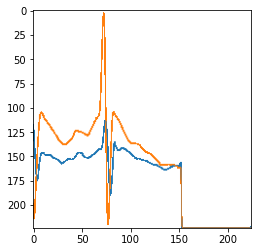

In [16]:
img = sequence_to_img(np.reshape(X_train[0], (2, 300)))
plt.imshow(img)

### 2. Feature Extraction - VGG16

- load VGG16 model

In [17]:
#model_vgg16 = VGG16(weights='imagenet', include_top=False)

In [18]:
model_resnet50 = ResNet50(weights='imagenet', include_top=False)

C:\Users\yunus\Anaconda3\envs\GPU_ENV\lib\site-packages\keras_applications\resnet50.py:265: UserWarning: The output shape of `ResNet50(include_top=False)` has been changed since Keras 2.2.0.
  warnings.warn('The output shape of `ResNet50(include_top=False)` '


In [19]:
# model_densenet121 = DenseNet121(weights='imagenet', include_top=False)

In [20]:
def get_feature(name, img):
    x = image.img_to_array(img)
    x = np.expand_dims(x, axis=0)
    if name == 'vgg16' :
        x = prepro_vgg16(x)
        feature = model_vgg16.predict(x)
        return feature
    elif name == 'resnet50' :
        x = prepro_resnet50(x)
        feature = model_resnet50.predict(x)
        return feature
    elif name == 'densenet121' :
        x = prepro_densenet121(x)
        feature = model_densenet121.predict(x)
        return feature
    else :
        raise("%s model not found" % name)

- transform Train image to feature using VGG16

In [22]:
#vgg16_features = []
resnet50_features = []
# densenet121_features = []

print("----- Feature Extraction for Train Dataset -------")
for i in range(len(X_train)):
    signal = np.reshape(X_train[i], (2, 300))
    img = sequence_to_img(signal)
    
    # calculate vgg16 feature     
#     vgg16_vec = get_feature('vgg16', img)
#     vgg16_features.append(vgg16_vec)
   
    # calculate resnet50 feature     
    resnet50_vec = get_feature('resnet50', img)
    resnet50_features.append(resnet50_vec)

    # calculate densenet121 feature     
#     densenet121_vec = get_feature('densenet121', img)
#     densenet121_features.append(densenet121_vec)
    
    if i % 500 == 0:
        tm = datetime.datetime.now().strftime("%H:%M:%S")
        print('[%s] - finish processing %d sample' % (tm, i))

----- Feature Extraction for Train Dataset -------
[22:52:04] - finish processing 0 sample
[22:58:11] - finish processing 500 sample
[23:04:17] - finish processing 1000 sample
[23:10:24] - finish processing 1500 sample
[23:16:31] - finish processing 2000 sample
[23:34:55] - finish processing 2500 sample
[03:56:20] - finish processing 3000 sample
[03:58:04] - finish processing 3500 sample
[03:59:48] - finish processing 4000 sample
[04:01:37] - finish processing 4500 sample
[04:03:29] - finish processing 5000 sample
[04:05:22] - finish processing 5500 sample
[04:07:16] - finish processing 6000 sample
[04:09:11] - finish processing 6500 sample
[04:11:08] - finish processing 7000 sample
[04:13:08] - finish processing 7500 sample
[04:15:04] - finish processing 8000 sample
[04:16:59] - finish processing 8500 sample
[04:18:55] - finish processing 9000 sample
[04:20:50] - finish processing 9500 sample
[04:22:45] - finish processing 10000 sample
[04:24:43] - finish processing 10500 sample
[04:2

- save feature extraction train dataset

In [26]:
#np.savez_compressed('dataset/train_vgg16_feature', vgg16_feature=vgg16_features)

In [44]:
np.array(resnet50_features[0]).shape

(1, 7, 7, 2048)

In [ ]:
np.savez_compressed('dataset/train_resnet51_feature', resnet50_feature=resnet50_features)

In [45]:
# np.savez_compressed('dataset/train_densenet121_feature', densenet121_feature=densenet121_features)

- save output (y) train data

In [46]:
#np.savez_compressed('dataset/train_y', y=y_train)

- transform Test image to feature using VGG16

In [ ]:
#vgg16_features = []
resnet50_features = []
# densenet121_features = []

print("----- Feature Extraction for Test Dataset -------")
for i in range(len(X_test)):
    # transform data     
    signal = np.reshape(X_test[i], (2, 300))
    img = sequence_to_img(signal)
    
    # calculate vgg16 feature     
#     vgg16_vec = get_feature('vgg16', img)
#     vgg16_features.append(vgg16_vec)
   
    # calculate resnet50 feature     
    resnet50_vec = get_feature('resnet50', img)
    resnet50_features.append(resnet50_vec)

    # calculate densenet121 feature     
#     densenet121_vec = get_feature('densenet121', img)
#     densenet121_features.append(densenet121_vec)
    
    if i % 500 == 0:
        tm = datetime.datetime.now().strftime("%H:%M:%S")
        print('[%s] - finish processing %d sample' % (tm, i))

- save feature extration test dataset

In [ ]:
#np.savez_compressed('dataset/test_vgg16_feature', vgg16_feature=vgg16_features)

In [ ]:
np.savez_compressed('dataset/test_resnet50_feature', resnet50_feature=resnet50_features)

In [ ]:
# np.savez_compressed('dataset/test_densenet121_feature', densenet121_feature=densenet121_features)

- save output (y) test data

In [ ]:
#np.savez_compressed('dataset/test_y', y=y_test)